---
title: "Lecture 21: Matrix decompositions, NMF"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture21_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Eigenvalue decomposition

Other than solving linear systems (or linear least-squares), the most important problem in numerical linear algebra is the eigenvalue problem.

## Eigenvalues and eigenvectors

::: {.callout-caution icon=false}
## Exercise: Do you recall the definition of eigenvalue and eigenvector?
Suppose $\mathbf{A}$ is a matrix, and $\lambda$ and $\mathbf{x}$ are an eigenvalue and eigenvector, respectively.  What do you know about $\mathbf{A}$, $\lambda$, and $\mathbf{x}$?  What is the relationship between them?  
:::
<details><summary>Answer:</summary> 
Given a square matrix $\mathbf{A}$, if 


$$\mathbf{A}\mathbf{x} = \lambda \mathbf{x}$$

for a scalar $\lambda$ and a nonzero vector $\mathbf{x}$, then $\lambda$ is an **eigenvalue** and $\mathbf{x}$ is an associated **eigenvector**.
</details>

## Eigenvalue decomposition

We can rewrite the eigenvalue definition as $(\mathbf{A} - \lambda\mathbf{I}) \mathbf{x} = \boldsymbol{0}$. Thus $(\mathbf{A} - \lambda\mathbf{I})$ is singular, and must have a zero determinant. 

. . .

The determinant $\det(\mathbf{A} - \lambda \mathbf{I})$ is called the **characteristic polynomial**. Its roots are the eigenvalues, so we know that an $n\times n$ matrix has $n$ eigenvalues, counting algebraic multiplicity. 

. . .

Suppose that $\mathbf{A}\mathbf{v}_k=\lambda_k\mathbf{v}_k$ for $k=1,\ldots,n$. We can summarize these as

\begin{align*}\begin{bmatrix}
    \mathbf{A}\mathbf{v}_1 & \mathbf{A}\mathbf{v}_2 & \cdots & \mathbf{A}\mathbf{v}_n
  \end{bmatrix}
  &=
    \begin{bmatrix}
      \lambda_1 \mathbf{v}_1 & \lambda_2\mathbf{v}_2 & \cdots & \lambda_n \mathbf{v}_n
    \end{bmatrix}, \\[1mm]
  \mathbf{A} \begin{bmatrix}
    \mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_n
  \end{bmatrix}
  &=
\begin{bmatrix}
    \mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_n
  \end{bmatrix}
  \begin{bmatrix}
    \lambda_1 & &  &  \\
    & \lambda_2 & & \\
    & & \ddots & \\
    & & & \lambda_n
\end{bmatrix},
\end{align*}
which we write as

. . .

$$\mathbf{A} \mathbf{V} = \mathbf{V} \mathbf{D}.$$

---

If $\mathbf{V}$ is a nonsingular matrix, then we arrive at the eigenvalue decomposition.

. . .

::: {.callout-note icon=false}
## Definition: Eigenvalue decomposition (EVD)
An **eigenvalue decomposition** (EVD) of a square matrix $\mathbf{A}$ is

$$\mathbf{A} = \mathbf{V} \mathbf{D} \mathbf{V}^{-1}.$$

If $\mathbf{A}$ has an EVD, we say that $\mathbf{A}$ is **diagonalizable**; otherwise $\mathbf{A}$ is **nondiagonalizable** (or *defective*).
:::

. . .

One simple example of a nondiagonalizable matrix is

$$\mathbf{B} = \begin{bmatrix}
    1 & 1\\0 & 1
  \end{bmatrix}.$$

. . .

There are instances in which we can guarantee an EVD exists. 

::: {.callout-warning icon=false}
## Theorem:
If the $n\times n$ matrix $\mathbf{A}$ has $n$ distinct eigenvalues, then $\mathbf{A}$ is diagonalizable. 
:::

## Conditioning of eigenvalues

Just as linear systems have condition numbers that quantify the effect of finite precision, eigenvalue problems may be poorly conditioned too. Many possible results exist, we will use just one.

::: {.callout-warning icon=false}
## Theorem: Bauer–Fike
Let $\mathbf{A}\in\mathbb{C}^{n\times n}$ be diagonalizable, $\mathbf{A}=\mathbf{V}\mathbf{D}\mathbf{V}^{-1}$, with eigenvalues $\lambda_1,\ldots,\lambda_n$. If $\mu$ is an eigenvalue of $\mathbf{A}+\mathbf{E}$ for a complex matrix $\mathbf{E}$, then

$$\min_{j=1,\ldots,n} |\mu - \lambda_j| \le \kappa(\mathbf{V}) \, \| \mathbf{E} \|\,,$$

where $\|\cdot\|$ and $\kappa$ are in the 2-norm.
:::

. . .

The Bauer–Fike theorem tells us that eigenvalues can be perturbed by an amount that is $\kappa(\mathbf{V})$ times larger than perturbations to the matrix. 

[This result is a bit less straightforward than it might seem—eigenvectors are not unique, so there are multiple possible values for $\kappa(\mathbf{V})$. Even so, the theorem indicates caution when a matrix has eigenvectors that form an ill-conditioned matrix. ]{.content-hidden when-format='revealjs' when-format='pptx'} 

. . .

The limiting case of $\kappa(\mathbf{V})=\infty$ might be interpreted as indicating a nondiagonalizable matrix $\mathbf{A}$. The other extreme is also of interest: $\kappa(\mathbf{V})=1$, which implies that $\mathbf{V}$ is unitary.

---

::: {.callout-note icon=false}
## Definition: Normal matrix
If $\mathbf{A}$ has an EVD with a unitary eigenvector matrix $\mathbf{V}$, then $\mathbf{A}$ is a **normal matrix**. 
:::

. . .

In Math 73, we refer to unitary matrices as **orthogonal** and normal matrices as **orthogonally diagonalizable matrices**.

. . .

Hermitian and real symmetric matrices are normal. Since the condition number of a unitary matrix is equal to 1, Bauer-Fike guarantees that a perturbation of a normal matrix changes the eigenvalues by the same amount or less.

---

In [29]:
# | echo: false
using MLDatasets
using Images, ImageShow
using LinearAlgebra
using NMF
using Random
using Plots

In [30]:
n = 7
A = randn(n,n) + 1im*randn(n,n)
A = (A+A')/2    # define a Hermitian matrix

λ,V = eigen(A)
@show cond(V);

cond(V) = 1.0000000000000007


. . .

In [31]:
ΔA = 1e-8*normalize(randn(n,n) + 1im*randn(n,n))
λ̃ = eigvals(A+ΔA)     # perturb the matrix and calculate the perturbed eigenvalues
dist = minimum( [abs(x-y) for x in λ̃, y in λ], dims=2 ) # measure the effect on evs

7×1 Matrix{Float64}:
 2.8621982126143585e-9
 6.81385035582749e-10
 9.046796029822398e-10
 2.789496888225541e-10
 6.166751082615822e-10
 1.2216561199825988e-9
 1.598605774006123e-9

. . .

As promised, the perturbation of the eigenvalues does not exceed the norm of the perturbation to the matrix.

---

Now, we try a triangular matrix.

In [32]:
n = 20
x = 1:n
A = triu( x*ones(n)' )
A[1:5,1:5]

5×5 Matrix{Float64}:
 1.0  1.0  1.0  1.0  1.0
 0.0  2.0  2.0  2.0  2.0
 0.0  0.0  3.0  3.0  3.0
 0.0  0.0  0.0  4.0  4.0
 0.0  0.0  0.0  0.0  5.0

. . .

In [33]:
λ,V = eigen(A)
@show cond(V);  # far from normal

cond(V) = 6.149906664929389e9


. . .

In [34]:
ΔA = 1e-8*normalize(randn(n,n) + 1im*randn(n,n))
λ̃ = eigvals(A+ΔA)
dist = minimum( [abs(x-y) for x in λ̃, y in λ], dims=2 )
BF_bound = cond(V)*norm(ΔA)      # eigenvalues can change by a lot more
@show maximum(dist),BF_bound;

(maximum(dist), BF_bound) = (0.07748582420436179, 61.499066649293894)


---

If we plot the eigenvalues of many perturbations, we get a cloud of points that roughly represents all the possible eigenvalues when representing this matrix with single-precision accuracy.

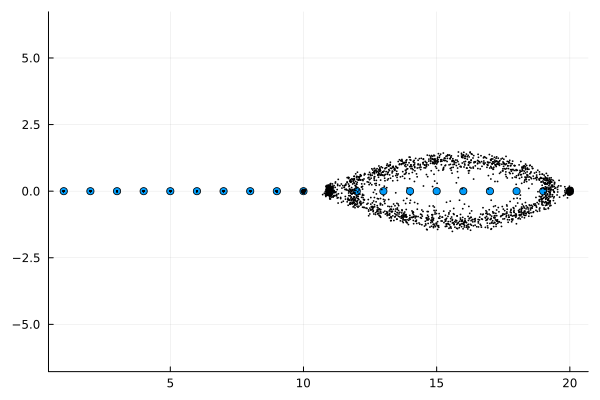

In [35]:
plt = scatter(λ,zeros(n),aspect_ratio=1, legend=false)
for _ in 1:200
    ΔA = eps(Float32)*normalize(randn(n,n) + 1im*randn(n,n))
    λ̃ = eigvals(A+ΔA)
    scatter!(real(λ̃),imag(λ̃),m=1,color=:black)
end
plt

. . .

Some eigenvalues are far more affected by the perturbation than others!

## Computing the EVD

In practice, root-finding on the characteristic polynomial is not used in numerical methods for eigenvalue computation. [In fact, numerical eigenvalue computation methods are often used to compute the roots of given polynomials.]{.content-hidden when-format='revealjs' when-format='pptx'} 

. . .

Many numerical methods use matrix powers, and build on the fact that the EVD simplifies matrix powers significantly:

. . .

$$\mathbf{A}^2 = \mathbf{V} \mathbf{D} \mathbf{V}^{-1} \mathbf{V} \mathbf{D} \mathbf{V}^{-1} = \mathbf{V} \mathbf{D}^2 \mathbf{V}^{-1}$$

. . .

and more generally,

. . .

$$\mathbf{A}^k = \mathbf{V} \mathbf{D}^k \mathbf{V}^{-1}.$$

. . .

If the eigenvalues have different magnitudes, then as $k \rightarrow \infty$ the entries on the diagonal of $\mathbf{D}^k$ will become increasingly well separated and easy to pick out.

---

In [36]:
D = diagm( [-6,-1,2,4,5] )
V,R = qr(randn(5,5))    # V is unitary
A = V*D*V'

5×5 Matrix{Float64}:
 1.71884    0.442572    0.401375   0.50617   0.517765
 0.442572  -0.0236562   1.19399    3.33321  -2.29173
 0.401375   1.19399     1.41403   -3.65011  -1.17993
 0.50617    3.33321    -3.65011   -1.50997  -1.05649
 0.517765  -2.29173    -1.17993   -1.05649   2.40075

In [37]:
eigvals(A)

5-element Vector{Float64}:
 -6.000000000000005
 -1.000000000000001
  1.9999999999999987
  4.000000000000002
  4.999999999999996

In [38]:
Q,R = qr(A)
A = R*Q;

In [39]:
eigvals(A)  # this is a similarity transformation, so the eigenvalues are unchanged

5-element Vector{Float64}:
 -5.999999999999996
 -0.9999999999999997
  1.9999999999999964
  4.000000000000003
  5.000000000000001

---

Interestingly, if we repeat this transformation many times, the resulting matrix converges to $\mathbf{D}$:

In [40]:
for k in 1:40
    Q,R = qr(A)
    A = R*Q
end
A

5×5 Matrix{Float64}:
 -6.0           0.0049553     1.25503e-6   -1.26275e-15   2.57233e-16
  0.0049553     5.0           0.000171875  -2.44292e-14   5.12839e-16
  1.25503e-6    0.000171875   4.0          -3.63019e-10   4.63596e-16
 -2.11382e-16  -2.40191e-14  -3.63021e-10   2.0           4.7017e-13
  2.24715e-31  -1.35075e-27   8.57213e-23   4.69617e-13  -1.0

. . .

The process demonstrated here is known as the *Francis QR iteration*, and it can be formulated as an $O(n^3)$ algorithm for finding the EVD. Such an algorithm is the foundation of what the `eigen` function uses.

# Singular value decomposition

The SVD is as fundamental as the EVD and very related to it!

## SVD

::: {.callout-note icon=false}
## Definition: Singular value decomposition (SVD)
The **singular value decomposition** of an $m\times n$ matrix $\mathbf{A}$ is

$$\mathbf{A} = \mathbf{U} \mathbf{S} \mathbf{V}^*,$$

where $\mathbf{U}\in\mathbb{C}^{m\times m}$ and $\mathbf{V}\in\mathbb{C}^{n\times n}$ are unitary and $\mathbf{S}\in\mathbb{R}^{m\times n}$ is real and diagonal with nonnegative elements.

The columns of $\mathbf{U}$ and $\mathbf{V}$ are called **left** and **right singular vectors**, respectively. The diagonal elements of $\mathbf{S}$, written $\sigma_1,\ldots,\sigma_r$, for $r=\min\{m,n\}$, are called the **singular values** of $\mathbf{A}$ and are ordered so that

$$\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_r\ge 0, \qquad r=\min\{m,n\}.$$

We call $\sigma_1$ the **principal singular value** and $\mathbf{u}_{1}$ and $\mathbf{v}_{1}$ the **principal singular vectors**. 
:::

. . .

::: {.callout-warning icon=false}
## Theorem: 
Every $m\times n$ matrix has an SVD. The singular values of a matrix are unique, but the singular vectors are not. If the matrix is real, then $\mathbf{U}$ and $\mathbf{V}$ in {eq}`svd` can be chosen to be real, orthogonal matrices. 
:::

## Connections to the EVD

::: {.callout-warning icon=false}
## Theorem: 
The nonzero eigenvalues of $\mathbf{A}^*\mathbf{A}$ are the squares of the singular values of $\mathbf{A}$.
:::

. . .

::: {.callout-caution icon=false}
## Exercise: Prove this!
:::

. . .

Another way to write $\mathbf{A}=\mathbf{U}\mathbf{S}\mathbf{V}^*$ is 

$$
\mathbf{A}\mathbf{V}=\mathbf{U}\mathbf{S}.
$$ 

. . .

Taken columnwise, this equation means

$$
\mathbf{A} \mathbf{v}_{k} = \sigma_k \mathbf{u}_{k}, \qquad k=1,\ldots,r=\min\{m,n\}.
$$

. . .

In words, each right singular vector is mapped by $\mathbf{A}$ to a scaled version of its corresponding left singular vector; the magnitude of scaling is its singular value.

. . .

This is like the EVD!  The SVD sacrifices having the same basis in both source and image spaces (they may not even have the same dimension).

## Thin form

We saw earlier in this course that a matrix has both *full* and *thin* forms of the QR factorization. A similar situation holds with the SVD. 

. . .

Suppose $\mathbf{A}$ is $m\times n$ with $m > n$ and let $\mathbf{A}=\mathbf{U}\mathbf{S}\mathbf{V}^*$ be an SVD. The last $m-n$ rows of $\mathbf{S}$ are all zero due to the fact that $\mathbf{S}$ is diagonal. Hence

\begin{align*}
  \mathbf{U} \mathbf{S} & =
  \begin{bmatrix}
    \mathbf{u}_1 & \cdots & \mathbf{u}_n & \mathbf{u}_{n+1} & \cdots & \mathbf{u}_m
  \end{bmatrix}
  \begin{bmatrix}
    \sigma_1 & &  \\
    & \ddots &  \\
    & & \sigma_n \\
    & & \\
    & \boldsymbol{0} & \\
    & &
  \end{bmatrix} =
  \begin{bmatrix}
    \mathbf{u}_1 & \cdots & \mathbf{u}_n
  \end{bmatrix}
  \begin{bmatrix}
    \sigma_1 & &  \\
    & \ddots &  \\
    & & \sigma_n
  \end{bmatrix} 
  \\&= \hat{\mathbf{U}} \hat{\mathbf{S}},
\end{align*}

in which $\hat{\mathbf{U}}$ is $m\times n$ and $\hat{\mathbf{S}}$ is $n\times n$. 

---

This allows us to define the **thin SVD** 

$$\mathbf{A}=\hat{\mathbf{U}}\hat{\mathbf{S}}\mathbf{V}^*,$$

in which $\hat{\mathbf{S}}$ is square and diagonal and $\hat{\mathbf{U}}$ is ONC but not square. 

## SVD and the 2-norm

The SVD is intimately connected to the 2-norm, as the following theorem describes. 

::: {.callout-warning icon=false}
## Theorem: 
Let $\mathbf{A}\in\mathbb{C}^{m\times n}$ have an SVD $\mathbf{A}=\mathbf{U}\mathbf{S}\mathbf{V}^*$. Then:

1. The 2-norm satisfies

    $$\| \mathbf{A} \|_2 = \sigma_1.$$

2. The rank of $\mathbf{A}$ is the number of nonzero singular values.

3. Let $r=\min\{m,n\}$. Then

    $$\kappa_2(\mathbf{A}) = \|\mathbf{A}\|_2\|\mathbf{A}^+\|_2 = \frac{\sigma_1}{\sigma_r},$$

    where a division by zero implies that $\mathbf{A}$ does not have full rank.
:::

---

In [41]:
A = [i^j for i=1:5, j=0:3]

5×4 Matrix{Int64}:
 1  1   1    1
 1  2   4    8
 1  3   9   27
 1  4  16   64
 1  5  25  125

In [42]:
σ = svdvals(A)

4-element Vector{Float64}:
 146.69715365883005
   5.738569780953702
   0.9998486640841027
   0.11928082685241923

In [43]:
@show opnorm(A,2);
@show σ[1];

opnorm(A, 2) = 146.69715365883005
σ[1] = 146.69715365883005


In [44]:
@show cond(A,2);
@show σ[1]/σ[end];

cond(A, 2) = 1229.846887633767
σ[1] / σ[end] = 1229.846887633767


---

In [45]:
U,σ,V = svd(A);    # thin form is default
@show size(U);
@show size(V);

size(U) = (5, 4)
size(V) = (4, 4)


In [46]:
@show opnorm(U'*U - I);   # verify orthogonality
@show opnorm(V'*V - I);

opnorm(U' * U - I) = 4.947764483928556e-16
opnorm(V' * V - I) = 7.570241024277813e-16


# Nonnegative matrix factorization

While the EVD and SVD are very fundamental matrix decompositions and have very clear linear algebraic interpretations, they are not the only decompositions of interest.  One very popular decomposition is the **nonnegative matrix factorization** (NMF) -- the nonnegativity of the factors makes it very interpretable.

## Nonnegative matrix factorization

::: {.callout-note icon=false}
## Definition: Nonnegative matrix factorization (NMF)
Given $\mathbf{A}\in\mathbb{R}^{m\times n}$, the **nonnegative matrix factorization** (NMF) of $\mathbf{A}$ is a decomposition of the form
$$\mathbf{A} \approx \mathbf{W} \mathbf{H},$$

where $\mathbf{W}\in\mathbb{R}^{m\times r}$ and $\mathbf{H}\in\mathbb{R}^{r\times n}$ are nonnegative matrices, and $r$ is the user-selected rank of the factorization.
:::

. . .

Note that this factorization is not exact -- one typically attempts to find $\mathbf{W}$ and $\mathbf{H}$ by minimizing some error between the data $\mathbf{A}$ and the approximation $\mathbf{W}\mathbf{H}$.

---

In [47]:
# Load MNIST data
train_x, _ = MNIST(split=:train)[:]
X = Float64.(reshape(train_x[:, :, 1:500], :, 500))  # Use first 500 digits

# Normalize pixel values
X ./= 255.0;

In [48]:
U, S, Vt = svd(X);

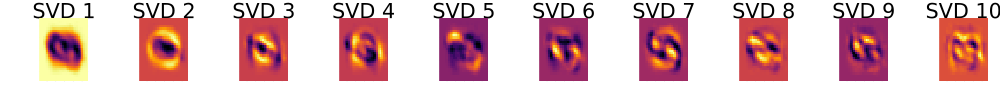

In [49]:
# Visualize first 10 SVD components (U columns)
function show_components(U, title_prefix)
    n = 10
    plt = plot(layout = (1, n), size = (100 * n, 100))
    for i in 1:n
        img = reshape(U[:, i], 28, 28)
        heatmap!(plt[i], img, axis = false, colorbar = false, title = "$title_prefix $i")
    end
    display(plt)
end

show_components(U, "SVD")

. . .

In [50]:
k = 10
model = nnmf(X, k; maxiter = 500)
W = model.W
H = model.H;

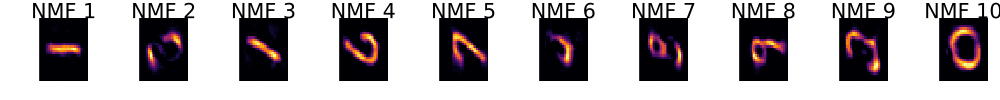

In [51]:
show_components(W, "NMF")

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->